# Libs

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.metrics import root_relative_squared_error
from sysidentpy.utils.generate_data import get_siso_data
from sysidentpy.utils.display_results import results
from sysidentpy.utils.plotting import plot_residues_correlation, plot_results
from sysidentpy.residues.residues_correlation import (
    compute_residues_autocorrelation,
    compute_cross_correlation,
)

In [4]:
x_train, x_valid, y_train, y_valid = get_siso_data(
    n=1000, colored_noise=False, sigma=0.0001, train_percentage=90
)

basis_function = Polynomial(degree=2)
estimator = LeastSquares()
model = FROLS(
    order_selection=True,
    n_info_values=3,
    ylag=2,
    xlag=2,
    info_criteria="aic",
    estimator=estimator,
    err_tol=None,
    basis_function=basis_function,
)
model.fit(X=x_train, y=y_train)
yhat = model.predict(X=x_valid, y=y_valid)
rrse = root_relative_squared_error(y_valid, yhat)
print(rrse)

0.00018808055899168535


In [5]:
r = pd.DataFrame(
    results(
        model.final_model,
        model.theta,
        model.err,
        model.n_terms,
        err_precision=8,
        dtype="sci",
    ),
    columns=["Regressors", "Parameters", "ERR"],
)
print(r)

      Regressors  Parameters             ERR
0        x1(k-2)  9.0000E-01  9.57218184E-01
1         y(k-1)  2.0000E-01  3.97301952E-02
2  x1(k-1)y(k-1)  9.9991E-02  3.05158639E-03


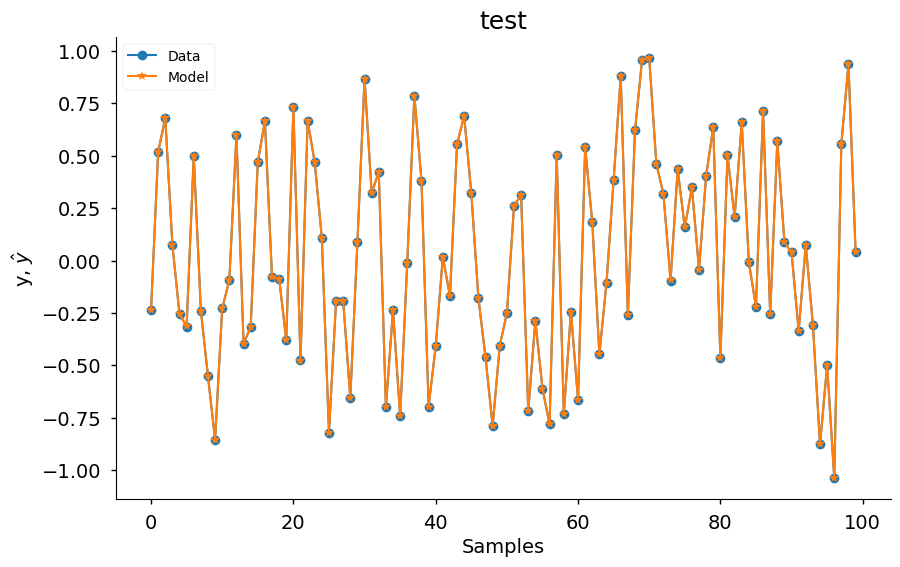

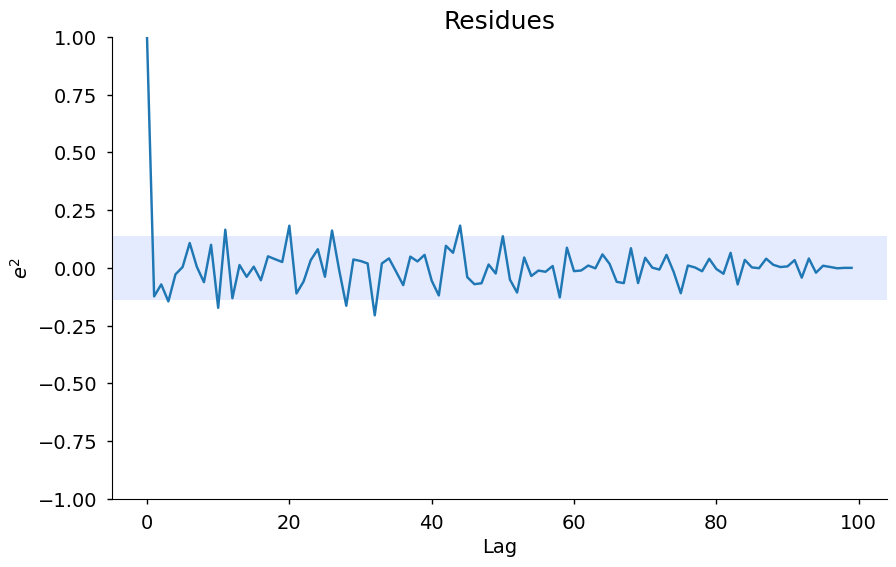

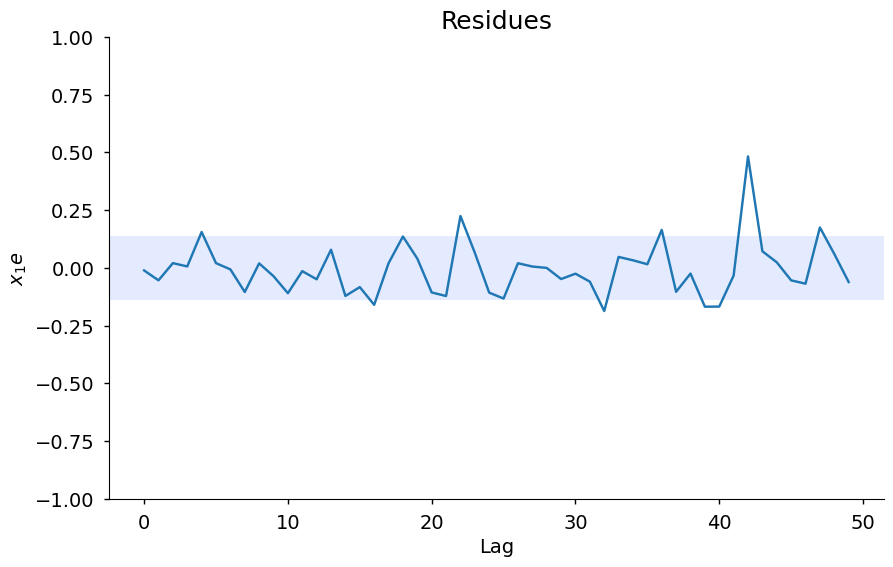

In [6]:
plot_results(
    y=y_valid,
    yhat=yhat,
    n=1000,
    title="test",
    xlabel="Samples",
    ylabel=r"y, $\hat{y}$",
    data_color="#1f77b4",
    model_color="#ff7f0e",
    marker="o",
    model_marker="*",
    linewidth=1.5,
    figsize=(10, 6),
    style="seaborn-v0_8-notebook",
    facecolor="white",
)
ee = compute_residues_autocorrelation(y_valid, yhat)
plot_residues_correlation(
    data=ee, title="Residues", ylabel="$e^2$", style="seaborn-v0_8-notebook"
)
x1e = compute_cross_correlation(y_valid, yhat, x_valid)
plot_residues_correlation(
    data=x1e, title="Residues", ylabel="$x_1e$", style="seaborn-v0_8-notebook"
)